### Requirements:
- Python 3.10 or later
- *Jupyter Notebook*
- *egglog*
- *graphviz*

In [ ]:
# for Google Colab
%cd /content/
!rm -rf nextmap
!git clone https://github.com/PigBrainOverflow/nextmap.git
%cd nextmap
!git checkout emap-egglog

In [ ]:
%pip install egglog graphviz

In [ ]:
import egglog
import emap
from emap.rewrites.basic import *
from emap.rewrites.retiming import *


netlist = egglog.EGraph()
w0 = netlist.let("w0", emap.Wire.from_dff(emap.Wire.from_input("w0")))
w1 = netlist.let("w1", emap.Wire.from_dff(emap.Wire.from_input("w1")))
w2 = netlist.let("w2", emap.Wire.from_dff(emap.Wire.from_input("w2")))
w3 = netlist.let("w3", emap.Wire.from_dff(emap.Wire.from_input("w3")))
wv0 = netlist.let("wv0", emap.WireVec.add(egglog.Vec[emap.Wire](w0, w1), egglog.Vec[emap.Wire](w2, w3)))

# const_inputs_rules, all_from_dffs_base_rules, all_from_dffs_iter_rule, union_dffs_iter_rule, arith_retiming_forward_rules

rules = egglog.ruleset(
    all_from_dffs_iter_rule,
    union_dffs_iter_rule
)

report = netlist.run((const_inputs_rules + all_from_dffs_base_rules + arith_retiming_forward_rules + rules) * 10)
# for name, count in report.num_matches_per_rule.items():
#     print(f"{name}: {count}")
netlist.display(graphviz=True)

Before saturation:


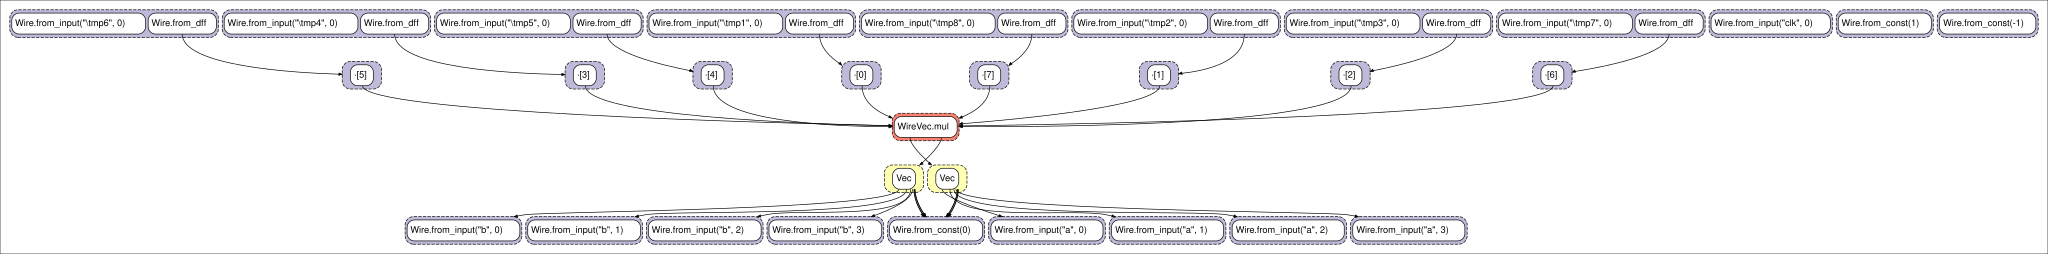

{('out', 0): 11, ('out', 1): 12, ('out', 2): 13, ('out', 3): 14, ('out', 4): 15, ('out', 5): 16, ('out', 6): 17, ('out', 7): 18}


In [2]:
"""
Retiming Example
"""
import emap
from emap.rewrites import *
import json

with open("good_multiplier_small.json", "r") as f:
    mod = json.load(f)["modules"]["top"]

netlist = emap.Netlist()
netlist.build_from_json(mod, clk="clk")
print("Before saturation:")
netlist.display(graphviz=True)
print(netlist._outputs)

# report = netlist.run((emap.misc_rules + emap.retiming_rules) * 100)

# print("After saturation:")
# netlist.display(graphviz=True)
# for rule, count in report.num_matches_per_rule.items():
#     print(f"{rule}: {count} applications")
# output_egraph = netlist._serialize()
# with open("output_egraph.json", "w") as f:
#     eg = json.loads(output_egraph.to_json())
#     json.dump(eg, f, indent=2)

In [ ]:
"""
WireVec Equivalence Example
"""
import emap
import egglog
from emap.core import Wire, WireVec

netlist = emap.Netlist()
wv0 = netlist.let("wv0", WireVec(egglog.Vec[Wire](Wire.from_input("w0"))))
wv1 = netlist.let("wv1", WireVec(egglog.Vec[Wire](Wire.from_input("w1"))))
wv2 = netlist.let("wv2", WireVec.add(2, wv0, wv1))
wv3 = netlist.let("wv3", WireVec(egglog.Vec[Wire](wv2[0], wv2[1])))
# wv2 == wv3

print("Before saturation:")
netlist.display(graphviz=True)

netlist.run(emap.misc_rules * 10)
netlist.check(egglog.eq(wv2).to(wv3))
print("After saturation:")
netlist.display(graphviz=True)

In [ ]:
"""
Retiming Example
"""
import emap
import json

with open("good_multiplier_1bit.json", "r") as f:
    mod = json.load(f)["modules"]["top"]

netlist = emap.Netlist()
netlist.build_from_json(mod, clk="clk")
print("Before saturation:")
netlist.display(graphviz=True)

# report = netlist.run((emap.misc_rules + emap.retiming_rules) * 100)

# print("After saturation:")
# netlist.display(graphviz=True)
# for rule, count in report.num_matches_per_rule.items():
#     print(f"{rule}: {count} applications")
# output_egraph = netlist._serialize()
# with open("output_egraph.json", "w") as f:
#     eg = json.loads(output_egraph.to_json())
#     json.dump(eg, f, indent=2)

In [ ]:
"""
Zero Extension Example
"""
import emap
import egglog
from emap.core import Wire, WireVec
from emap.rewrites.techlibs import xcup

netlist = emap.Netlist()
wv0 = netlist.let("wv0", WireVec(egglog.Vec[Wire](Wire.from_input("w0"), Wire.from_input("w1"), Wire.from_input("0"), Wire.from_input("0"))))
wv1 = netlist.let("wv1", WireVec(egglog.Vec[Wire](Wire.from_input("w2"), Wire.from_input("w3"), Wire.from_input("0"), Wire.from_input("0"))))
wv2 = netlist.let("wv2", WireVec.mul(4, wv0, wv1))
# wv2 == wv3

print("Before saturation:")
netlist.display(graphviz=True)

netlist.run(emap.misc_rules * 10 + xcup.dsp_rules* 10)  # you need schedule techlib rules after others
print("After saturation:")
netlist.display(graphviz=True)

In [ ]:
"""
Retiming Example
"""
import emap
import json

with open("bad_multiplier.json", "r") as f:
    mod = json.load(f)["modules"]["top"]

netlist = emap.Netlist()
netlist.build_from_json(mod, clk="clk")
report = netlist.run(emap.misc_rules * 100)
print("Before saturation:")
netlist.display(graphviz=True)

# report = netlist.run((emap.misc_rules + emap.retiming_rules) * 100)

# print("After saturation:")
# netlist.display(graphviz=True)
# for rule, count in report.num_matches_per_rule.items():
#     print(f"{rule}: {count} applications")
output_egraph = netlist._serialize()
with open("output_egraph.json", "w") as f:
    eg = json.loads(output_egraph.to_json())
    json.dump(eg, f, indent=2)